In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/clinvar_result.txt", sep="\t")

In [3]:
df.shape

(2432, 25)

In [4]:
df.columns

Index(['Name', 'Gene(s)', 'Protein change', 'Condition(s)', 'Accession',
       'GRCh37Chromosome', 'GRCh37Location', 'GRCh38Chromosome',
       'GRCh38Location', 'VariationID', 'AlleleID(s)', 'dbSNP ID',
       'Canonical SPDI', 'Variant type', 'Molecular consequence',
       'Germline classification', 'Germline date last evaluated',
       'Germline review status', 'Somatic clinical impact',
       'Somatic clinical impact date last evaluated',
       'Somatic clinical impact review status', 'Oncogenicity classification',
       'Oncogenicity date last evaluated', 'Oncogenicity review status',
       'Unnamed: 24'],
      dtype='object')

In [5]:
df.head()

,Name,Gene(s),Protein change,Condition(s),Accession,GRCh37Chromosome,GRCh37Location,GRCh38Chromosome,GRCh38Location,VariationID,...,Germline classification,Germline date last evaluated,Germline review status,Somatic clinical impact,Somatic clinical impact date last evaluated,Somatic clinical impact review status,Oncogenicity classification,Oncogenicity date last evaluated,Oncogenicity review status,Unnamed: 24
0,GRCh38/hg38 2p25.3-22.3(chr2:12770-33711509)x3,ABHD1|ACP1|ADAM17|ADCY3|ADGRF3|ADI1|AGBL5|AGBL...,NaN,See cases,VCV000153441,2.0,12770 - 33936576,2.0,12770 - 33711509,153441,...,Pathogenic,"Jun 18, 2013",no assertion criteria provided,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GRCh38/hg38 2p25.3-23.2(chr2:30341-28419664)x3,LOC126806103|LOC126806104|LOC126806105|LOC1268...,NaN,See cases,VCV000146072,2.0,30341 - 28642531,2.0,30341 - 28419664,146072,...,Pathogenic,"Jul 30, 2009",no assertion criteria provided,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GRCh38/hg38 2p25.3-16.1(chr2:66097-55570637)x3,ABCG5|ABCG8|ABHD1|ACP1|ACYP2|ADAM17|ADCY3|ADGR...,NaN,See cases,VCV000059133,2.0,66097 - 55797773,2.0,66097 - 55570637,59133,...,Pathogenic,"Aug 12, 2011","criteria provided, single submitter",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GRCh38/hg38 2p25.3-21(chr2:236816-45983232)x3,ABCG5|ABCG8|ABHD1|ACP1|ADAM17|ADCY3|ADGRF3|ADI...,NaN,See cases,VCV000155615,2.0,236816 - 46210371,2.0,236816 - 45983232,155615,...,Pathogenic,"Nov 19, 2013",no assertion criteria provided,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GRCh38/hg38 2p25.1-11.2(chr2:7495123-87705899)x3,AAK1|ABCG5|ABCG8|ABHD1|ACTG2|ACTR2|ACYP2|ADAM1...,NaN,See cases,VCV000152995,2.0,7635254 - 88005418,2.0,7495123 - 87705899,152995,...,Benign,"Feb 4, 2013",no assertion criteria provided,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df["Germline classification"].value_counts()

Germline classification
Likely benign                                   1111
Uncertain significance                           499
Conflicting classifications of pathogenicity     231
Pathogenic                                       225
Likely pathogenic                                139
Benign                                           118
Benign/Likely benign                              48
Pathogenic/Likely pathogenic                      26
not provided                                      26
Name: count, dtype: int64

In [7]:
colonne_da_rimuovere = [
    "Somatic clinical impact",
    "Somatic clinical impact date last evaluated",
    "Somatic clinical impact review status",
    "Oncogenicity classification",
    "Oncogenicity date last evaluated",
    "Oncogenicity review status",
    "Unnamed: 24"
]

df = df.drop(columns=colonne_da_rimuovere)
df.shape

(2432, 18)

In [8]:
df["Variant type"].value_counts()

Variant type
single nucleotide variant    2183
Deletion                      126
Duplication                    55
Microsatellite                 24
copy number gain               17
Indel                          12
Insertion                      11
copy number loss                4
Name: count, dtype: int64

In [9]:
df["Molecular consequence"].value_counts()

Molecular consequence
missense variant                                         651
intron variant                                           642
synonymous variant                                       631
frameshift variant                                       111
nonsense                                                  98
splice donor variant                                      56
splice acceptor variant                                   44
synonymous variant|intron variant                         34
missense variant|intron variant                           29
3 prime UTR variant                                       19
missense variant|3 prime UTR variant                      12
5 prime UTR variant                                        9
synonymous variant|3 prime UTR variant                     7
inframe_deletion                                           6
inframe_insertion                                          6
missense variant|5 prime UTR variant                       3
5 

In [10]:
df["Condition(s)"].value_counts().head(15)

Condition(s)
not provided                                                                  1547
Autosomal recessive nonsyndromic hearing loss 9                                190
Inborn genetic diseases                                                        102
not specified|not provided|Autosomal recessive nonsyndromic hearing loss 9      81
not specified|not provided                                                      78
not specified                                                                   72
not provided|Autosomal recessive nonsyndromic hearing loss 9                    51
not provided|not specified                                                      30
Autosomal recessive nonsyndromic hearing loss 9|not provided                    27
Inborn genetic diseases|not provided                                            27
Auditory neuropathy                                                             20
Nonsyndromic genetic hearing loss                                         

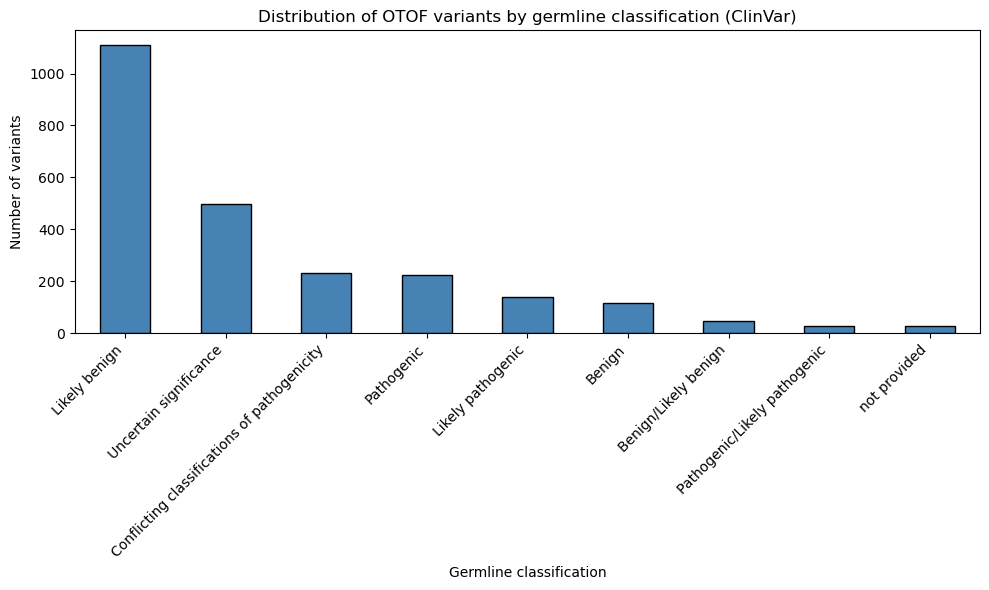

In [11]:
# Count of variants by variant type
counts = df["Germline classification"].value_counts()

# Bar chart
plt.figure(figsize=(10, 6))
counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Distribution of OTOF variants by germline classification (ClinVar)")
plt.xlabel("Germline classification")
plt.ylabel("Number of variants")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

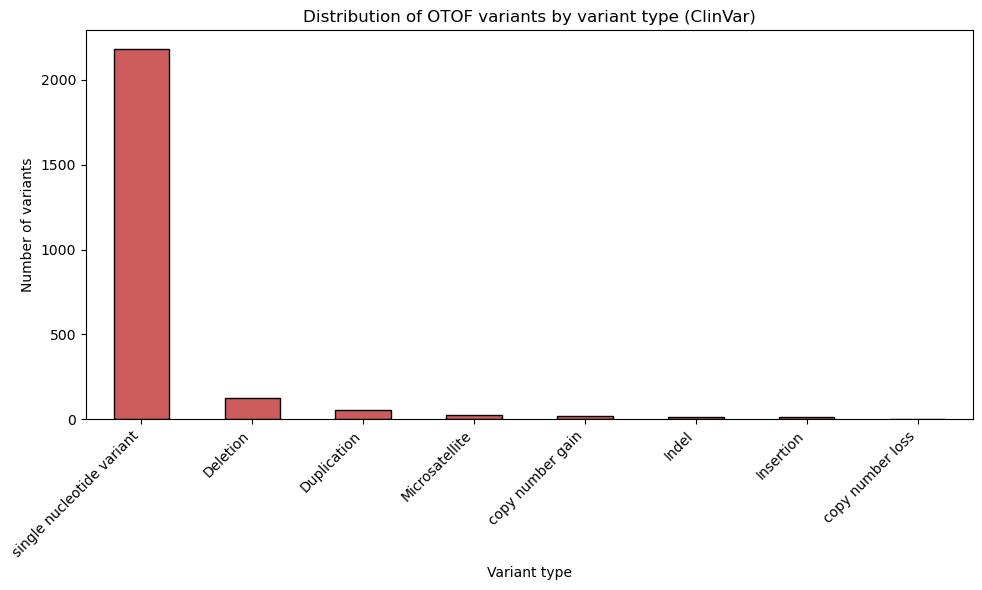

In [12]:
# Count of variants by variant type
counts_type = df["Variant type"].value_counts()

# Bar chart
plt.figure(figsize=(10, 6))
counts_type.plot(kind="bar", color="indianred", edgecolor="black")
plt.title("Distribution of OTOF variants by variant type (ClinVar)")
plt.xlabel("Variant type")
plt.ylabel("Number of variants")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

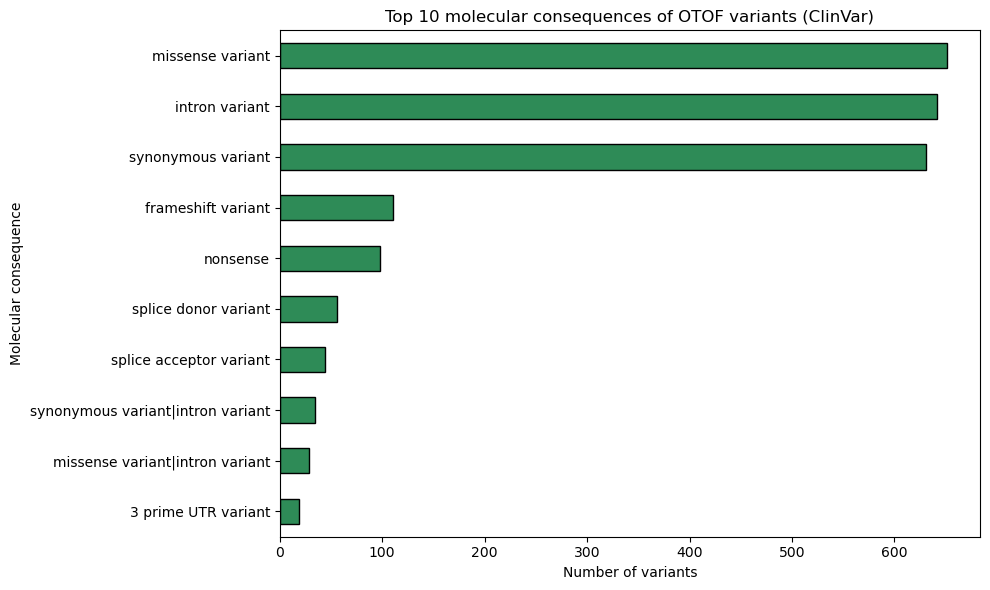

In [13]:
# Top 10 molecular consequences (the long tail is ignored for readability)
counts_consequence = df["Molecular consequence"].value_counts().head(10)

# Horizontal bar chart (better for long labels)
plt.figure(figsize=(10, 6))
counts_consequence.plot(kind="barh", color="seagreen", edgecolor="black")
plt.title("Top 10 molecular consequences of OTOF variants (ClinVar)")
plt.xlabel("Number of variants")
plt.ylabel("Molecular consequence")
plt.gca().invert_yaxis()  # most frequent at the top
plt.tight_layout()
plt.show()

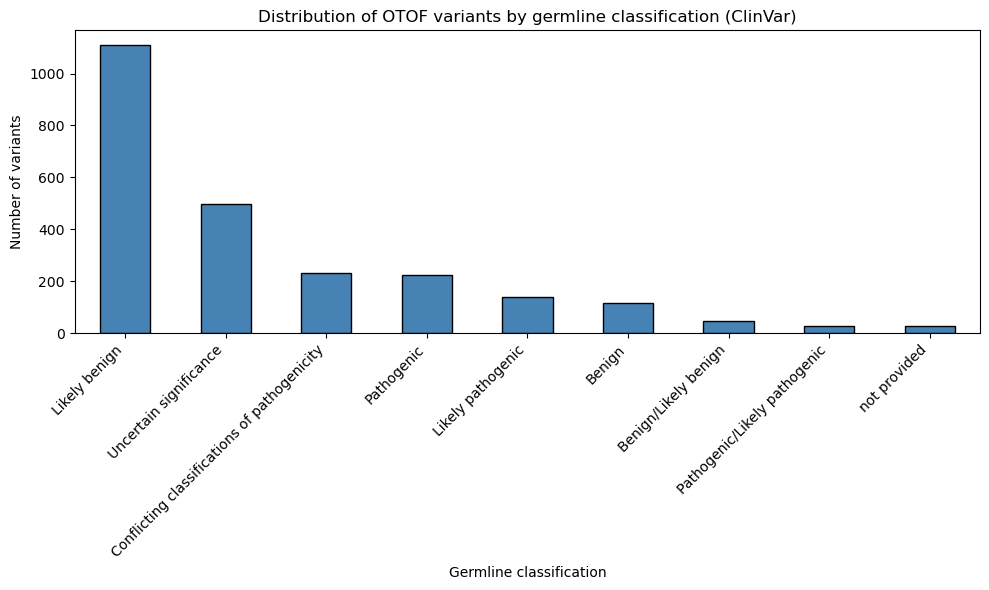

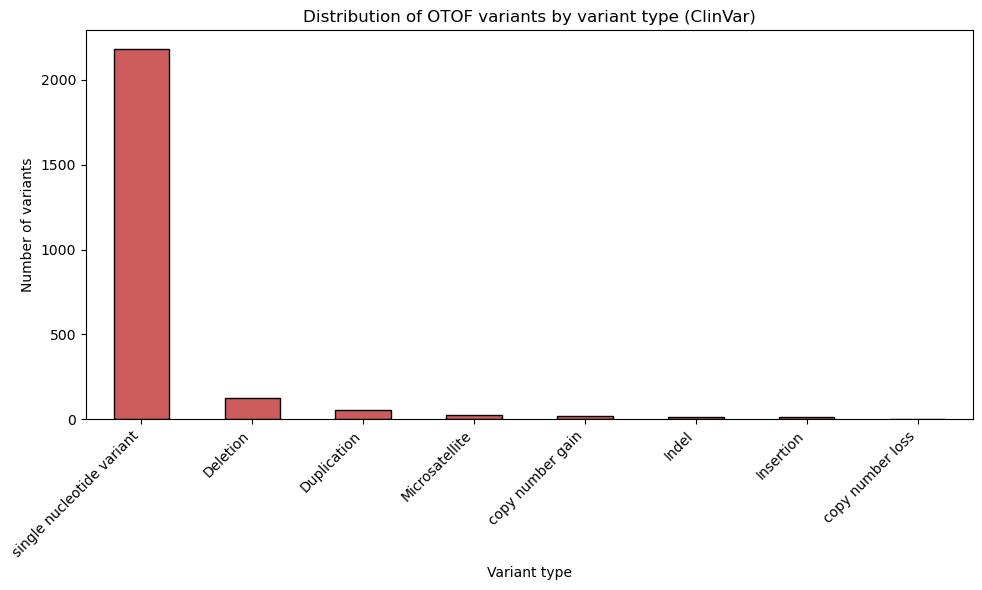

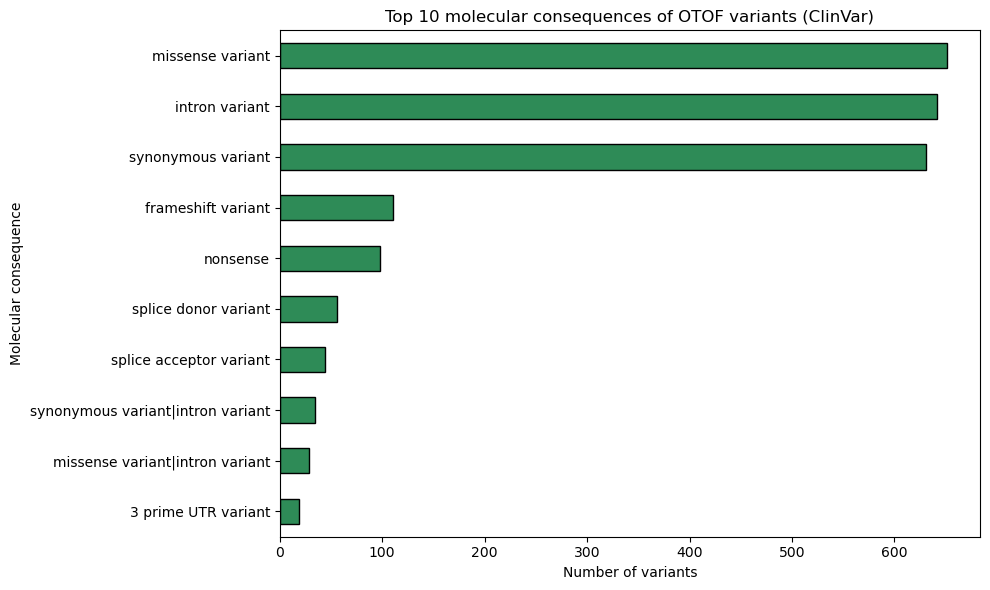

In [14]:
# === Figure 1: Germline classification ===
counts = df["Germline classification"].value_counts()

plt.figure(figsize=(10, 6))
counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Distribution of OTOF variants by germline classification (ClinVar)")
plt.xlabel("Germline classification")
plt.ylabel("Number of variants")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../results/classification_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# === Figure 2: Variant type ===
counts_type = df["Variant type"].value_counts()

plt.figure(figsize=(10, 6))
counts_type.plot(kind="bar", color="indianred", edgecolor="black")
plt.title("Distribution of OTOF variants by variant type (ClinVar)")
plt.xlabel("Variant type")
plt.ylabel("Number of variants")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../results/variant_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# === Figure 3: Top 10 molecular consequences ===
counts_consequence = df["Molecular consequence"].value_counts().head(10)

plt.figure(figsize=(10, 6))
counts_consequence.plot(kind="barh", color="seagreen", edgecolor="black")
plt.title("Top 10 molecular consequences of OTOF variants (ClinVar)")
plt.xlabel("Number of variants")
plt.ylabel("Molecular consequence")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../results/molecular_consequence_top10.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# Cross-tabulation: molecular consequence vs germline classification
crosstab = pd.crosstab(
    df["Molecular consequence"],
    df["Germline classification"]
)
crosstab

Germline classification,Benign,Benign/Likely benign,Conflicting classifications of pathogenicity,Likely benign,Likely pathogenic,Pathogenic,Pathogenic/Likely pathogenic,Uncertain significance,not provided
Molecular consequence,,,,,,,,,
3 prime UTR variant,2,1,1,3,1,0,0,11,0
3 prime UTR variant|intron variant,0,0,0,0,0,0,0,0,1
5 prime UTR variant,0,2,2,0,0,0,0,5,0
5 prime UTR variant|intron variant,2,1,0,0,0,0,0,0,0
5 prime UTR variant|missense variant|intron variant,0,0,0,0,0,0,0,1,0
5 prime UTR variant|synonymous variant|intron variant,0,0,0,1,0,0,0,0,0
frameshift variant,0,0,0,0,29,68,6,0,8
frameshift variant|3 prime UTR variant,0,0,0,0,0,1,1,0,0
frameshift variant|intron variant,0,0,0,0,1,1,0,0,0


In [16]:
# Focus on the most clinically relevant consequences
key_consequences = [
    "missense variant",
    "synonymous variant",
    "intron variant",
    "nonsense",
    "frameshift variant",
    "splice donor variant",
    "splice acceptor variant",
]

# Filter the dataframe to keep only these consequences
df_key = df[df["Molecular consequence"].isin(key_consequences)]

print(f"Variants kept after filtering: {len(df_key)} out of {len(df)}")

Variants kept after filtering: 2233 out of 2432


In [17]:
# Cross-tabulation on the filtered dataset
crosstab_key = pd.crosstab(
    df_key["Molecular consequence"],
    df_key["Germline classification"]
)
crosstab_key

Germline classification,Benign,Benign/Likely benign,Conflicting classifications of pathogenicity,Likely benign,Likely pathogenic,Pathogenic,Pathogenic/Likely pathogenic,Uncertain significance,not provided
Molecular consequence,,,,,,,,,
frameshift variant,0,0,0,0,29,68,6,0,8
intron variant,89,7,24,483,3,3,0,30,0
missense variant,10,12,132,55,23,12,8,391,7
nonsense,0,1,0,0,12,74,5,0,5
splice acceptor variant,0,0,1,0,27,10,3,2,1
splice donor variant,0,0,1,0,29,18,2,2,3
synonymous variant,11,19,55,528,0,0,0,15,0


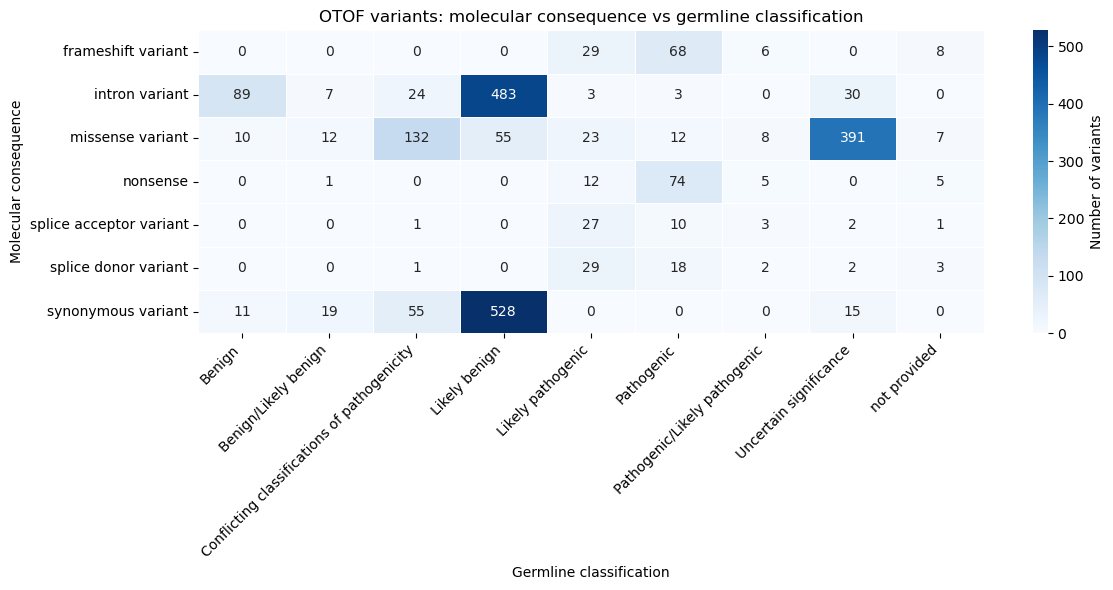

In [18]:
# Heatmap visualization
plt.figure(figsize=(12, 6))
sns.heatmap(
    crosstab_key,
    annot=True,           # show numbers inside cells
    fmt="d",              # format numbers as integers
    cmap="Blues",         # blue color palette
    cbar_kws={"label": "Number of variants"},
    linewidths=0.5,
    linecolor="white"
)
plt.title("OTOF variants: molecular consequence vs germline classification")
plt.xlabel("Germline classification")
plt.ylabel("Molecular consequence")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/heatmap_consequence_vs_classification.png", dpi=300, bbox_inches="tight")
plt.show()

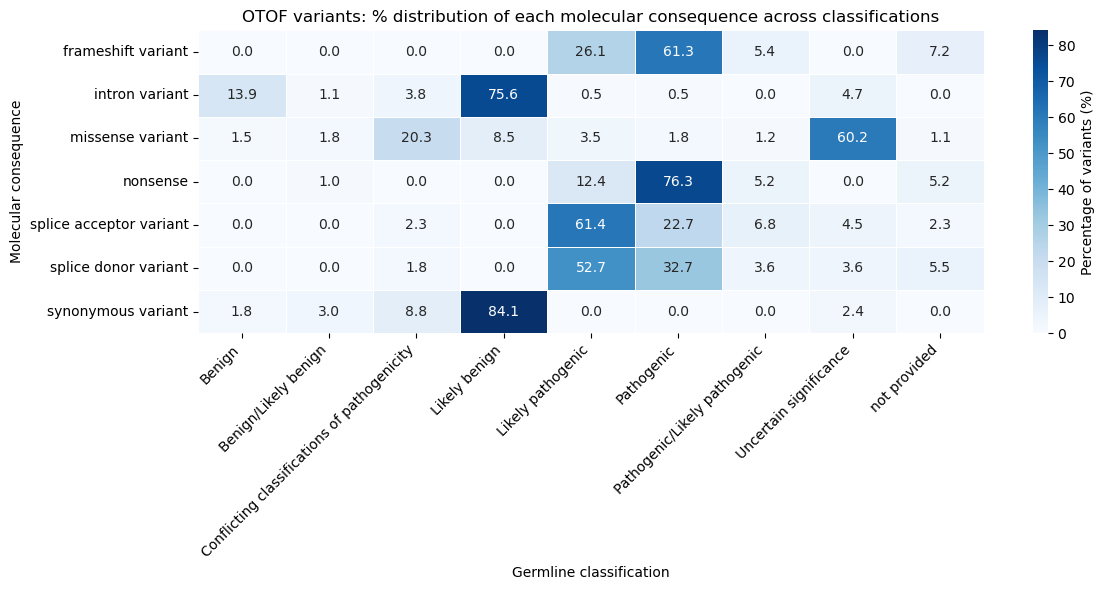

In [19]:
# Normalize crosstab by row (percentage of each consequence in each class)
crosstab_normalized = pd.crosstab(
    df_key["Molecular consequence"],
    df_key["Germline classification"],
    normalize="index"  # normalize by row
) * 100  # convert to percentages

# Heatmap of normalized values
plt.figure(figsize=(12, 6))
sns.heatmap(
    crosstab_normalized,
    annot=True,
    fmt=".1f",            # one decimal place
    cmap="Blues",
    cbar_kws={"label": "Percentage of variants (%)"},
    linewidths=0.5,
    linecolor="white"
)
plt.title("OTOF variants: % distribution of each molecular consequence across classifications")
plt.xlabel("Germline classification")
plt.ylabel("Molecular consequence")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/heatmap_consequence_vs_classification_normalized.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
crosstab_key.loc["frameshift variant"]

Germline classification
Benign                                           0
Benign/Likely benign                             0
Conflicting classifications of pathogenicity     0
Likely benign                                    0
Likely pathogenic                               29
Pathogenic                                      68
Pathogenic/Likely pathogenic                     6
Uncertain significance                           0
not provided                                     8
Name: frameshift variant, dtype: int64

In [21]:
# Synonymous variant distribution
crosstab_key.loc["synonymous variant"]

Germline classification
Benign                                           11
Benign/Likely benign                             19
Conflicting classifications of pathogenicity     55
Likely benign                                   528
Likely pathogenic                                 0
Pathogenic                                        0
Pathogenic/Likely pathogenic                      0
Uncertain significance                           15
not provided                                      0
Name: synonymous variant, dtype: int64

In [22]:
# Missense variant distribution
crosstab_key.loc["missense variant"]

Germline classification
Benign                                           10
Benign/Likely benign                             12
Conflicting classifications of pathogenicity    132
Likely benign                                    55
Likely pathogenic                                23
Pathogenic                                       12
Pathogenic/Likely pathogenic                      8
Uncertain significance                          391
not provided                                      7
Name: missense variant, dtype: int64

In [23]:
# Save key statistics for README
summary = {
    "Total OTOF variants in ClinVar": len(df),
    "Frameshift - pathogenic (P+LP+P/LP)": 68 + 29 + 6,
    "Frameshift - total": 111,
    "Synonymous - benign (B+LB+B/LB)": 11 + 19 + 528,
    "Synonymous - total": 628,
    "Missense - VUS+Conflicting": 391 + 132,
    "Missense - total": 650,
}

for key, value in summary.items():
    print(f"{key}: {value}")

Total OTOF variants in ClinVar: 2432
Frameshift - pathogenic (P+LP+P/LP): 103
Frameshift - total: 111
Synonymous - benign (B+LB+B/LB): 558
Synonymous - total: 628
Missense - VUS+Conflicting: 523
Missense - total: 650
